In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    sr:float
    bpb:float
    boundary_percentage:float
    summary:str





In [9]:
def calculate_sr(state: BatsmanState):
    sr = (state["runs"] / state["balls"]) * 100
    return {"sr": sr}


def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours'] + state['sixes'])
    return {"bpb": bpb}

def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percentage': boundary_percent}

def generate_summary(state: BatsmanState):
    summary = f"The batsman scored {state['runs']} runs off {state['balls']} balls with a strike rate of {state['sr']:.2f}. He hit {state['fours']} fours and {state['sixes']} sixes, with a boundary percentage of {state['boundary_percentage']:.2f}%."
    return {"summary": summary}

In [10]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('generate_summary', generate_summary)

# edges

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'generate_summary')
graph.add_edge('calculate_bpb', 'generate_summary')
graph.add_edge('calculate_boundary_percent', 'generate_summary')

graph.add_edge('generate_summary', END)

workflow = graph.compile()

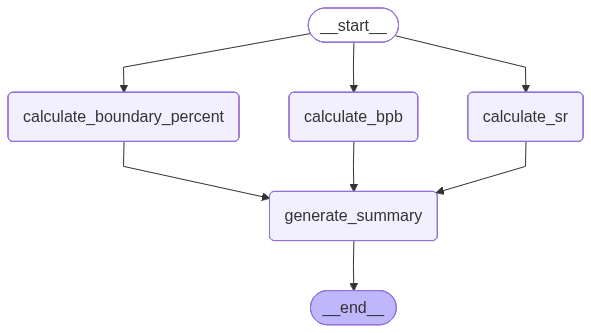

In [11]:
workflow

In [12]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percentage': 48.0,
 'summary': 'The batsman scored 100 runs off 50 balls with a strike rate of 200.00. He hit 6 fours and 4 sixes, with a boundary percentage of 48.00%.'}